### Importing Depedencies

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, recall_score, precision_score, precision_recall_curve
)
from sklearn.svm import OneClassSVM
import joblib
import scipy.sparse as sp
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

### Loading Data from the pipeline

In [5]:
x_train = sp.load_npz("x_train_processed.npz")
x_test = sp.load_npz("x_test_processed.npz")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")
feature_names = np.load("feature_names.npy", allow_pickle=True)
preprocessing_pipeline = joblib.load("preprocessing_pipeline.joblib")

print("x_train:", x_train.shape, "| x_test:", x_test.shape)
print("y_train class balance:", np.bincount(y_train) / len(y_train))
print("y_test  class balance:", np.bincount(y_test) / len(y_test))

# attack_cat, aligned to the same rows as y_train/y_test -- for the Stage-2 model
y_cat_train = np.load("y_cat_train.npy", allow_pickle=True)
y_cat_test = np.load("y_cat_test.npy", allow_pickle=True)
print("attack_cat classes (train):", np.unique(y_cat_train))

x_train: (1647192, 79) | x_test: (411799, 79)
y_train class balance: [0.95160613 0.04839387]
y_test  class balance: [0.95160503 0.04839497]
attack_cat classes (train): ['Analysis' 'Backdoors' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']


### Evalution Helper

In [6]:
def evalute_model (name, y_true, y_pred, y_score = None):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_true, y_pred, target_names=["Normal", "Attack"], digits=3))
    recall = recall_score(y_true, y_pred)
    precision = precision_score (y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 score:  {f1:.4f}")
    metrics = {"Model": name, "recall": recall, "Precisin":precision, "F1": f1}
    if y_score is not None:
        roc_auc = roc_auc_score(y_true, y_score)
        print(f"ROC-AUC:   {roc_auc:.4f}")
        metrics["roc_auc"] = roc_auc
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize = (4,4))
    ConfusionMatrixDisplay(cm, display_labels= ['Normal', 'Attack']).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()
    fn = cm[1,0]
    print(f"Missed attacks (FN): {fn} out of {cm[1].sum()} actual attacks")
    return metrics
results = []

### Get started with MODELS: 

1. STAGE 1# : Random Forest

class_weight="balanced" compensates for the ~95/5 split without discarding data. Recall on the attack class is the metric to watch here: a missed attack (false negative) is far costlier than a false alarm, because false alarms just get re-checked by Stage 2 / an analyst, while a missed attack passes through undetected.


Random Forest
              precision    recall  f1-score   support

      Normal      1.000     0.985     0.992    391870
      Attack      0.772     1.000     0.871     19929

    accuracy                          0.986    411799
   macro avg      0.886     0.992     0.932    411799
weighted avg      0.989     0.986     0.987    411799

Recall:    0.9999
Precision: 0.7718
F1 score:  0.8712
ROC-AUC:   0.9990


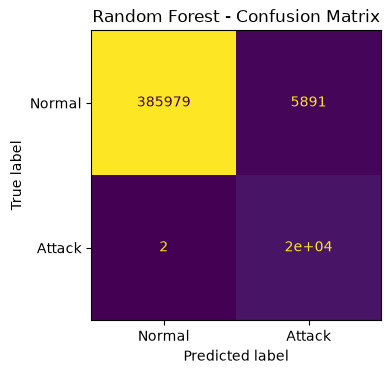

Missed attacks (FN): 2 out of 19929 actual attacks


In [7]:
stage1_model_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,         
    max_features='sqrt',   
    min_samples_leaf=5,   
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

stage1_model_rf.fit(x_train, y_train)
rf_pred = stage1_model_rf.predict(x_test)
rf_proba = stage1_model_rf.predict_proba(x_test)[:,1]
results.append(evalute_model("Random Forest", y_test,rf_pred, rf_proba))

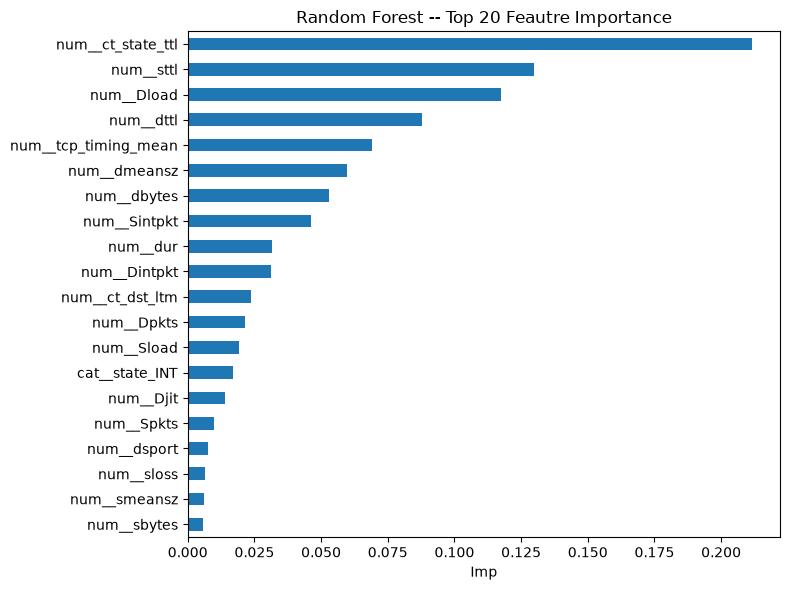

First 20 Top Features based on Random Forest Model:


num__ct_state_ttl       0.211493
num__sttl               0.129975
num__Dload              0.117331
num__dttl               0.087708
num__tcp_timing_mean    0.068992
num__dmeansz            0.059665
num__dbytes             0.053025
num__Sintpkt            0.046059
num__dur                0.031433
num__Dintpkt            0.031153
num__ct_dst_ltm         0.023777
num__Dpkts              0.021499
num__Sload              0.019281
cat__state_INT          0.016950
num__Djit               0.013962
num__Spkts              0.010008
num__dsport             0.007771
num__sloss              0.006404
num__smeansz            0.006082
num__sbytes             0.005607
dtype: float64

In [8]:
importances = pd.Series(stage1_model_rf.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize = (8,6))
importances.head(20).plot(kind= 'barh')
plt.gca().invert_yaxis()
plt.title("Random Forest -- Top 20 Feautre Importance")
plt.xlabel("Imp")
plt.tight_layout()
plt.show()
print("First 20 Top Features based on Random Forest Model:")
importances.head(20)

2. STAGE 1# : Random Forest with SMOTE

Class weighting reweights the loss; SMOTE generates synthetic minority-class samples so the model literally sees more attack examples during training. Neither is strictly better in general — comparing both on this specific dataset tells us which approach the data responds to.

Leakage discipline: SMOTE is fit only on x_train/y_train, never on x_test. Fitting it on the full dataset (or on test) would let synthetic samples "see" real test-set patterns, inflating validation metrics unrealistically.

Before SMOTE:  [1567478   79714]
After SMOTE:  [1567478 1567478]

Random Forest + SMOTE
              precision    recall  f1-score   support

      Normal      1.000     0.985     0.992    391870
      Attack      0.772     1.000     0.871     19929

    accuracy                          0.986    411799
   macro avg      0.886     0.992     0.932    411799
weighted avg      0.989     0.986     0.987    411799

Recall:    0.9999
Precision: 0.7721
F1 score:  0.8713
ROC-AUC:   0.9989


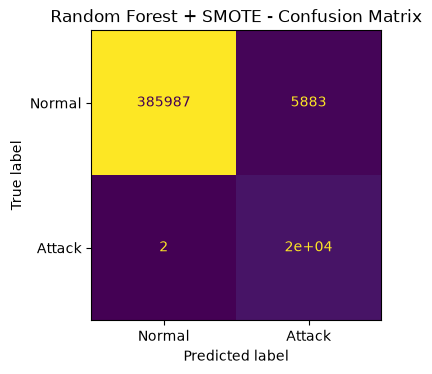

Missed attacks (FN): 2 out of 19929 actual attacks


In [9]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state= RANDOM_STATE)
x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)
print ("Before SMOTE: ", np.bincount(y_train))
print ("After SMOTE: ", np.bincount(y_train_sm))
stage1_model_rf_smote = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,         
    max_features='sqrt',   
    min_samples_leaf=5,   
    n_jobs=-1,
    random_state=RANDOM_STATE
)
stage1_model_rf_smote.fit(x_train_sm, y_train_sm)
rf_smote_pred = stage1_model_rf_smote.predict(x_test)
rf_smote_proba = stage1_model_rf_smote.predict_proba(x_test)[:,1]
results.append(evalute_model("Random Forest + SMOTE", y_test,rf_smote_pred, rf_smote_proba))

3. STAGE 1#: XGBoosting 

XGBoost typically edges out Random Forest on structured/tabular intrusion data because of its sequential error-correction (boosting) — later trees specifically focus on the examples earlier trees got wrong, which tends to help disproportionately on a hard minority class like this one.

scale_pos_weight is XGBoost's equivalent of class_weight="balanced" — set it to the negative:positive ratio in the training set only.

Scale Pos Weight = 19.66

XGBoosting
              precision    recall  f1-score   support

      Normal      1.000     0.985     0.992    391870
      Attack      0.772     1.000     0.871     19929

    accuracy                          0.986    411799
   macro avg      0.886     0.992     0.932    411799
weighted avg      0.989     0.986     0.987    411799

Recall:    0.9999
Precision: 0.7715
F1 score:  0.8710
ROC-AUC:   0.9991


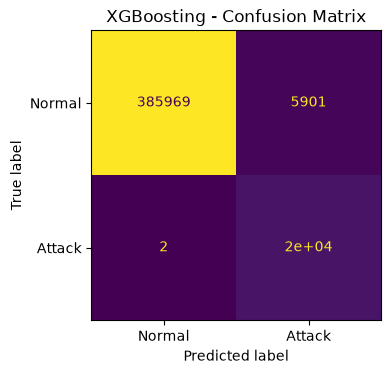

Missed attacks (FN): 2 out of 19929 actual attacks


In [10]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"Scale Pos Weight = {scale_pos_weight:.2f}")

stage1_model_xgboost = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=6,                # XGB defaults shallow — unlike RF, deep trees hurt here
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,   # handles imbalance like class_weight='balanced'
    tree_method='hist',          # <-- the big speed lever, use this always
    n_jobs=-1,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)
stage1_model_xgboost.fit(x_train, y_train)
xgb_pred = stage1_model_xgboost.predict(x_test)
xgb_proba = stage1_model_xgboost.predict_proba(x_test)[:,1]
results.append(evalute_model("XGBoosting", y_test, xgb_pred, xgb_proba))

- --> Insights: From above supervised learning, there is a good mertics of recall & percision with only 2 FN results. However, XGBoosting showed un explainable feature importance unlike other Ensample models of Random Forest which show propagation of feature importance

4. STAGE 1# : Unsupervised Anomaly Detection - One Class SVM & Isolation Forest

In [11]:
x_train.shape, x_test.shape

((1647192, 79), (411799, 79))


One-Class SVM (subsampled, normal-only training)
              precision    recall  f1-score   support

      Normal      0.917     0.919     0.918      5000
      Attack      0.919     0.917     0.918      5000

    accuracy                          0.918     10000
   macro avg      0.918     0.918     0.918     10000
weighted avg      0.918     0.918     0.918     10000

Recall:    0.9174
Precision: 0.9185
F1 score:  0.9180
ROC-AUC:   0.9625


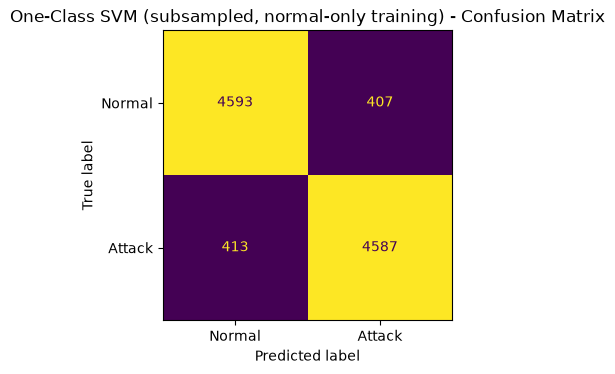

Missed attacks (FN): 413 out of 5000 actual attacks


In [12]:
# We will use small partition of data in this model OCSVM's RBF 
# kernel is O(n²)-O(n³) and needs dense input
# full-scale training would be infeasible on memory/time
N_OCSVM_TRAIN = 50_000
N_OCSVM_TEST = 10_000
normal_idx_train = np.where(y_train == 0)[0]
ocsvm_train_idx = np.random.choice(normal_idx_train, size = N_OCSVM_TRAIN, replace = False)
x_train_ocsvm = x_train[ocsvm_train_idx]

normal_idx_test = np.where(y_test == 0) [0]
attack_idx_test = np.where(y_test == 1) [0]
eval_normal =  np.random.choice(normal_idx_test, size=min (N_OCSVM_TEST//2, len(normal_idx_test)), replace = False )
eval_attack =  np.random.choice(attack_idx_test, size=min (N_OCSVM_TEST//2, len(attack_idx_test)), replace = False )

eval_idx = np.concatenate([eval_normal, eval_attack])

x_eval_ocsvm = x_test[eval_idx]
y_eval_ocsvm = y_test[eval_idx]

stage1_model_ocsvm = OneClassSVM(kernel= 'rbf', nu = 0.08, gamma='scale') #(Radial Basis Function), nu controls the expected fraction of anomalies (boundary complexity), gamma controls how much influence each training sample has.
stage1_model_ocsvm.fit(x_train_ocsvm.toarray())
ocsvm_raw_pred = stage1_model_ocsvm.predict(x_eval_ocsvm.toarray())
ocsvm_pred = (ocsvm_raw_pred == -1).astype(int)
ocsvm_proba = -stage1_model_ocsvm.decision_function(x_eval_ocsvm.toarray()) # higher score = more anomalous

results.append(evalute_model("One-Class SVM (subsampled, normal-only training)", y_eval_ocsvm, ocsvm_pred, ocsvm_proba))

In [13]:
ocsvm_proba


array([-79.66240019, -44.61001266, -94.98136467, ..., 213.95221985,
       152.73909645,  38.94720504], shape=(10000,))


One-Class SVM (tuned threshold, held-out eval)
              precision    recall  f1-score   support

      Normal      0.908     0.927     0.917      2473
      Attack      0.927     0.908     0.917      2527

    accuracy                          0.917      5000
   macro avg      0.917     0.918     0.917      5000
weighted avg      0.918     0.917     0.917      5000

Recall:    0.9082
Precision: 0.9269
F1 score:  0.9174
ROC-AUC:   0.9656


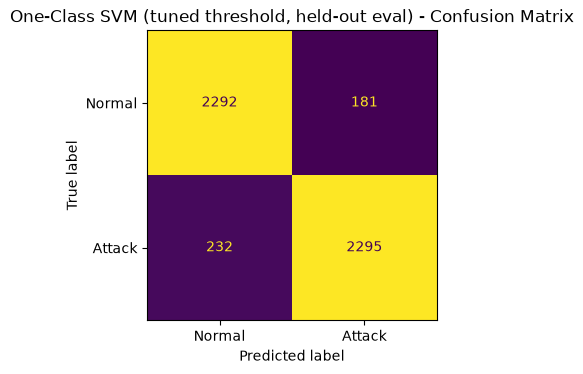

Missed attacks (FN): 232 out of 2527 actual attacks


In [14]:
# Hold out a separate slice for threshold selection, untouched by final reporting
rng = np.random.default_rng(RANDOM_STATE)
val_idx, final_test_idx = np.split(rng.permutation(eval_idx), [len(eval_idx) // 2])

x_val, y_val = x_test[val_idx], y_test[val_idx]
x_final, y_final = x_test[final_test_idx], y_test[final_test_idx]

val_score = -stage1_model_ocsvm.decision_function(x_val.toarray())
precisions, recalls, thresholds = precision_recall_curve(y_val, val_score)

candidates = np.where(recalls[:-1] >= 0.90)[0]
best_idx = candidates[np.argmax(precisions[candidates])]
best_threshold = thresholds[best_idx]

# Only now touch the held-out slice, once, for the number you actually report
final_score = -stage1_model_ocsvm.decision_function(x_final.toarray())
final_pred = (final_score >= best_threshold).astype(int)
results.append(evalute_model("One-Class SVM (tuned threshold, held-out eval)", y_final, final_pred, final_score))


Isolation Forest (tuned threshold, held-out eval)
              precision    recall  f1-score   support

      Normal      0.995     0.939     0.966    196034
      Attack      0.429     0.904     0.582      9866

    accuracy                          0.938    205900
   macro avg      0.712     0.921     0.774    205900
weighted avg      0.968     0.938     0.948    205900

Recall:    0.9035
Precision: 0.4287
F1 score:  0.5815
ROC-AUC:   0.9639


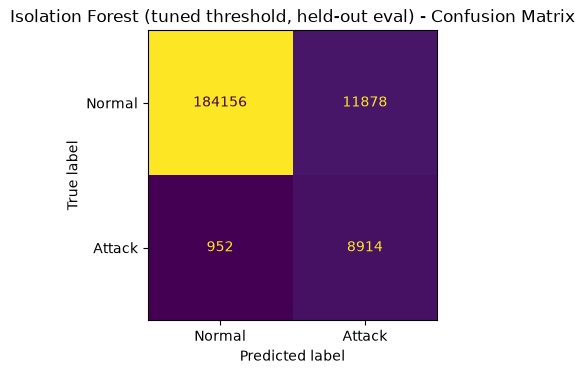

Missed attacks (FN): 952 out of 9866 actual attacks


In [15]:
# --- Isolation Forest: fit on normal-only training data ---
x_train_normal = x_train[y_train == 0]

stage1_model_iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",   
    n_jobs=-1,
    random_state=RANDOM_STATE
)
stage1_model_iso_forest.fit(x_train_normal)

rng = np.random.default_rng(RANDOM_STATE)
test_idx_all = np.arange(x_test.shape[0])
val_idx, final_idx = np.split(rng.permutation(test_idx_all), [len(test_idx_all) // 2])

x_val, y_val = x_test[val_idx], y_test[val_idx]
x_final, y_final = x_test[final_idx], y_test[final_idx]

val_score = -stage1_model_iso_forest.decision_function(x_val)
precisions, recalls, thresholds = precision_recall_curve(y_val, val_score)

candidates = np.where(recalls[:-1] >= 0.90)[0]
best_idx = candidates[np.argmax(precisions[candidates])]
best_threshold = thresholds[best_idx]

final_score = -stage1_model_iso_forest.decision_function(x_final)
final_pred = (final_score >= best_threshold).astype(int)

results.append(evalute_model("Isolation Forest (tuned threshold, held-out eval)", y_final, final_pred, final_score))

### OCSVM — Fair, Full-Scale Comparison

The two OCSVM evaluations above both score great, but both are tested on an artificially **balanced** eval set (5,000 normal / 5,000 attack). Isolation Forest, right above, is tested on the **full test set at its true 95/5 imbalance**. That's an apples-to-oranges comparison — a balanced eval set structurally inflates precision for any anomaly detector, regardless of real model quality.

OCSVM's *training* set has to stay small (RBF kernel is O(n²)-O(n³)), but there's no reason its *evaluation* set has to be small or balanced. Below we keep the same 50k-sample-trained model and re-score it on a much larger, realistically-imbalanced slice of the test set — same methodology used for Isolation Forest — so the comparison is finally fair.

Fair-eval class balance: [0.9496 0.0504]

One-Class SVM (small-sample trained, FAIR full-scale eval)
              precision    recall  f1-score   support

      Normal      0.995     0.927     0.959      4755
      Attack      0.389     0.906     0.544       245

    accuracy                          0.926      5000
   macro avg      0.692     0.916     0.752      5000
weighted avg      0.965     0.926     0.939      5000

Recall:    0.9061
Precision: 0.3888
F1 score:  0.5441
ROC-AUC:   0.9640


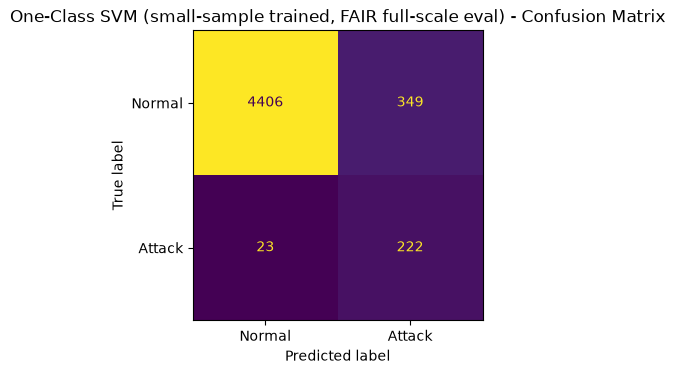

Missed attacks (FN): 23 out of 245 actual attacks


In [16]:
N_FAIR_TEST = 10_000
fair_idx=rng.choice(len(y_test), size= min(N_FAIR_TEST, len(y_test)), replace= False)
x_fair = x_test[fair_idx]
y_fair = y_test[fair_idx]
print("Fair-eval class balance:", np.bincount(y_fair) / len(y_fair))
val_idx, final_idx = np.split(rng.permutation(len(y_fair)), [len(y_fair) // 2])
x_val_fair, y_val_fair = x_fair[val_idx], y_fair[val_idx]
x_final_fair, y_final_fair = x_fair[final_idx], y_fair[final_idx]

val_score_fair = -stage1_model_ocsvm.decision_function(x_val_fair.toarray())
precisions, recalls, thresholds = precision_recall_curve(y_val_fair, val_score_fair)

candidates = np.where(recalls[:-1] >= 0.90)[0]
best_threshold_fair = thresholds[candidates[np.argmax(precisions[candidates])]]

final_score_fair = -stage1_model_ocsvm.decision_function(x_final_fair.toarray())
final_pred_fair = (final_score_fair >= best_threshold_fair).astype(int)

results.append(evalute_model(
    "One-Class SVM (small-sample trained, FAIR full-scale eval)",
    y_final_fair, final_pred_fair, final_score_fair
))

# Summary of STAGE 1# Models

In [17]:
summary_table = pd.DataFrame(results).sort_values(by= 'F1', ascending= False).reset_index().drop("index", axis= 1)
summary_table

,Model,recall,Precisin,F1,roc_auc
0,"One-Class SVM (subsampled, normal-only training)",0.917400,0.918502,0.917951,0.962539
1,"One-Class SVM (tuned threshold, held-out eval)",0.908192,0.926898,0.917450,0.965643
2,Random Forest + SMOTE,0.999900,0.772065,0.871335,0.998936
3,Random Forest,0.999900,0.771826,0.871183,0.998970
4,XGBoosting,0.999900,0.771527,0.870992,0.999104
5,"Isolation Forest (tuned threshold, held-out eval)",0.903507,0.428723,0.581512,0.963880
6,"One-Class SVM (small-sample trained, FAIR full...",0.906122,0.388792,0.544118,0.963996


- --> Insights: The best Recall / Precision Tradeoff is XGBoosting & Random Forest and as the two versions of Random Forests is approxiamtly the same, we will take into considration the version without SMOTE (with class weighted hyperparamter) and XGboost to do hyperparameters tuning ad take the best one.

### Hyper Parameters Tuning for XGBoost 

In [18]:
xgb_param_dist  = {"n_estimators": [50, 70, 100, 200],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    n_jobs=1,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=25,
    scoring="recall",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=4,              # capped, not -1 -- avoids oversubscribing/duplicating
                            # the 1.6M-row training matrix across too many processes
    pre_dispatch="2*n_jobs",  # limits how many jobs loky queues up at once (memory)
    error_score="raise",   # surface the real exception instead of a masked remote one
    verbose=2,
)

xgb_search.fit(x_train, y_train)

print("Best XGBoost params:", xgb_search.best_params_)
print("Best CV recall:", xgb_search.best_score_)

stage1_model_xgboost_tuned = xgb_search.best_estimator_
xgb_tuned_pred = stage1_model_xgboost_tuned.predict(x_test)
xgb_tuned_proba = stage1_model_xgboost_tuned.predict_proba(x_test)[:, 1]

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best XGBoost params: {'n_estimators': 70, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.3}
Best CV recall: 0.9998996418468055



XGBoosting (tuned)
              precision    recall  f1-score   support

      Normal      1.000     0.983     0.992    391870
      Attack      0.755     1.000     0.860     19929

    accuracy                          0.984    411799
   macro avg      0.877     0.992     0.926    411799
weighted avg      0.988     0.984     0.985    411799

Recall:    0.9999
Precision: 0.7548
F1 score:  0.8602
ROC-AUC:   0.9972


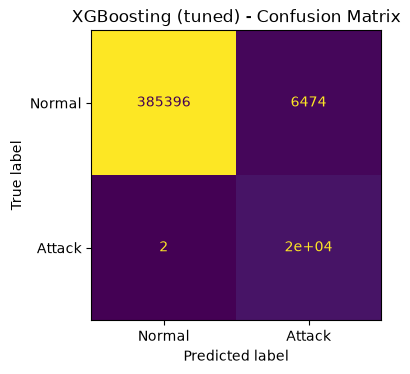

Missed attacks (FN): 2 out of 19929 actual attacks


In [19]:
results.append(evalute_model("XGBoosting (tuned)", y_test, xgb_tuned_pred, xgb_tuned_proba))

In [20]:
# Compare importance types -- > Feature Imprortance 
# alon might be misleading parameter as it can give 
# only one feature the importance for only being used 
# for a much time than others (it is just for spliting 
# the tree for many times)
for imp_type in ["weight", "gain", "cover"]:
    imp = pd.Series(
        stage1_model_xgboost_tuned.get_booster().get_score(importance_type=imp_type),
        name=imp_type
    )
    print(imp.sort_values(ascending=False).head(10))

f1     150.0
f24     98.0
f5      70.0
f38     70.0
f15     56.0
f16     46.0
f42     42.0
f13     26.0
f60     26.0
f29     18.0
Name: weight, dtype: float64
f5     1.757873e+06
f24    3.751416e+03
f38    3.720517e+03
f1     3.588712e+03
f52    3.135104e+03
f15    2.075292e+03
f13    1.525163e+03
f16    1.489392e+03
f42    7.566942e+02
f60    5.395421e+02
Name: gain, dtype: float64
f5     708921.937500
f38    346560.843750
f24    281711.062500
f42    250614.578125
f60    238520.515625
f1     181635.968750
f15     77870.515625
f52      3006.750977
f29      2582.695801
f16      1403.153320
Name: cover, dtype: float64


In [21]:
joblib.dump(stage1_model_xgboost_tuned, "stage1_xgboost_tuned.joblib")

['stage1_xgboost_tuned.joblib']

Stage 1 answers one question: is this traffic normal or an attack? Stage 2 only ever runs on the traffic Stage 1 has already flagged as an attack, and answers a second question: *which* of the attack categories is it (Exploits, DoS, Reconnaissance, Fuzzers, Generic, Analysis, Backdoors, Shellcode, Worms)? Training Stage 2 on the full dataset (including the ~95% Normal rows) would waste capacity on a distinction Stage 1 already makes, so Stage 2 trains and is evaluated on the attack-only subset (`attack_cat != "Normal"`).

In [22]:
train_attack_mask = y_cat_train != 'Normal'   
test_attack_mask  = y_cat_test  != 'Normal'   
                                              

x_train_atk = x_train[train_attack_mask]
x_test_atk = x_test[test_attack_mask]

y_cat_train_atk = y_cat_train[train_attack_mask]
y_cat_test_atk = y_cat_test[test_attack_mask]
print("Stage 2 train shape:", x_train_atk.shape, "| Stage 2 test shape:", x_test_atk.shape)
print("\nAttack category distribution (train):")
print(pd.Series(y_cat_train_atk).value_counts())

cat_encoder = LabelEncoder()
y_cat_train_enc = cat_encoder.fit_transform(y_cat_train_atk)
y_cat_test_enc = cat_encoder.transform(y_cat_test_atk)

n_classes = len(cat_encoder.classes_)
print("Attack Categories: ", list(cat_encoder.classes_))

Stage 2 train shape: (79714, 79) | Stage 2 test shape: (19929, 79)

Attack category distribution (train):
Exploits          22137
Generic           20222
Fuzzers           17478
Reconnaissance    10731
DoS                4525
Analysis           1738
Backdoors          1553
Shellcode          1194
Worms               136
Name: count, dtype: int64
Attack Categories:  ['Analysis', 'Backdoors', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']


The attack categories are themselves heavily imbalanced (Generic/Exploits dominate, Worms/Backdoors/Shellcode are rare), so `sample_weight` (balanced) is used at fit time -- XGBoost's multiclass objective doesn't take a `class_weight` argument the way sklearn's RandomForestClassifier does, so per-sample weighting is the equivalent lever here.

In [23]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weight = compute_sample_weight(class_weight='balanced', y= y_cat_train_enc)
stage2_model_xgb = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    n_estimators=50,
    max_depth=8,
    learning_rate=0.1,
    tree_method="hist",
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

stage2_model_xgb.fit(x_train_atk, y_cat_train_enc, sample_weight=sample_weight)

cat_pred_enc = stage2_model_xgb.predict(x_test_atk)
cat_pred = cat_encoder.inverse_transform(cat_pred_enc)

In [24]:
print(classification_report(y_cat_test_atk, cat_pred, digits=3))

                precision    recall  f1-score   support

      Analysis      0.174     0.522     0.261       446
     Backdoors      0.131     0.428     0.201       430
           DoS      0.465     0.422     0.442      1140
      Exploits      0.917     0.737     0.817      5462
       Fuzzers      0.981     0.900     0.939      4317
       Generic      0.984     0.896     0.938      5156
Reconnaissance      0.847     0.846     0.847      2626
     Shellcode      0.773     0.991     0.869       317
         Worms      0.384     0.943     0.545        35

      accuracy                          0.803     19929
     macro avg      0.629     0.743     0.651     19929
  weighted avg      0.877     0.803     0.832     19929



In [25]:
from sklearn.model_selection import train_test_split

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_atk, y_cat_train_enc,
    test_size=0.15, stratify=y_cat_train_enc, random_state=RANDOM_STATE
)

stage2_param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}

stage2_base = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    tree_method="hist",
    eval_metric="mlogloss",
    n_jobs=1,
    random_state=RANDOM_STATE,
)

cv2 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

stage2_search = RandomizedSearchCV(
    stage2_base,
    param_distributions=stage2_param_dist,
    n_iter=25,
    scoring="f1_macro",       
                               
    cv=cv2,
    random_state=RANDOM_STATE,
    n_jobs=4,                 
    pre_dispatch="2*n_jobs",
    error_score="raise",
    verbose=2,
)

sample_weight_tr = compute_sample_weight(class_weight="balanced", y=y_tr)
stage2_search.fit(x_tr, y_tr, sample_weight=sample_weight_tr)

print("Best Stage 2 params:", stage2_search.best_params_)
print("Best CV macro-F1:", stage2_search.best_score_)

stage2_model_xgb_tuned = stage2_search.best_estimator_

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Stage 2 params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.85}
Best CV macro-F1: 0.7410358965812534


In [26]:
cat_pred_tuned_enc = stage2_model_xgb_tuned.predict(x_test_atk)
cat_pred_tuned = cat_encoder.inverse_transform(cat_pred_tuned_enc)

print(classification_report(y_cat_test_atk, cat_pred_tuned, digits=3))

                precision    recall  f1-score   support

      Analysis      0.170     0.596     0.264       446
     Backdoors      0.148     0.407     0.218       430
           DoS      0.443     0.419     0.431      1140
      Exploits      0.913     0.735     0.814      5462
       Fuzzers      0.985     0.899     0.940      4317
       Generic      0.984     0.890     0.935      5156
Reconnaissance      0.852     0.847     0.849      2626
     Shellcode      0.746     0.981     0.847       317
         Worms      0.457     0.914     0.610        35

      accuracy                          0.801     19929
     macro avg      0.633     0.743     0.656     19929
  weighted avg      0.875     0.801     0.830     19929



In [27]:
joblib.dump(stage2_model_xgb_tuned, "stage2_xgboost_tuned.joblib")
joblib.dump(cat_encoder, "stage2_label_encoder.joblib")
print("Stage 2 model + label encoder saved.")

Stage 2 model + label encoder saved.


In [28]:
joblib.dump(stage1_model_rf, "stage1_random_forest.joblib")
joblib.dump(stage1_model_rf_smote, "stage1_random_forest_smote.joblib")
joblib.dump(stage1_model_xgboost, "stage1_xgboost_baseline.joblib")
joblib.dump(stage1_model_ocsvm, "stage1_ocsvm.joblib")
joblib.dump(stage1_model_iso_forest, "stage1_isolation_forest.joblib")

print("All Stage 1 models saved.")

All Stage 1 models saved.


# Final Pipeline to Stream Testing Data

In [29]:
def two_stages_predict(X, stage1_model, stage2_model, cat_encoder):
    """
    Run the full two-stage IDS pipeline on a feature matrix X.

    Stage 1 flags each row Normal/Attack. Only rows flagged Attack are
    passed to Stage 2, which predicts the specific attack category.
    Rows flagged Normal short-circuit and are labeled "Normal" without
    ever being scored by Stage 2.

    Parameters
    ----------
    X : sparse or dense matrix, shape (n_samples, n_features)
        Already-preprocessed features (same pipeline used for x_train/x_test).
    stage1_model : fitted binary classifier with .predict / .predict_proba
    stage2_model : fitted multiclass classifier with .predict
    cat_encoder  : fitted LabelEncoder used for Stage 2's attack_cat labels

    Returns
    -------
    final_labels : np.ndarray of object, shape (n_samples,)
        "Normal" or one of the attack category names, per row.
    stage1_pred  : np.ndarray, binary Stage 1 predictions (0/1).
    stage1_proba : np.ndarray, Stage 1 predicted attack probability.
    """
    stage1_pred = stage1_model.predict(X)
    stage1_proba = stage1_model.predict_proba(X)[:, 1]

    final_labels = np.full(X.shape[0], "Normal", dtype=object)

    attack_idx = np.where(stage1_pred == 1)[0]
    if len(attack_idx) > 0:
        X_attack = X[attack_idx]
        stage2_pred_enc = stage2_model.predict(X_attack)
        stage2_pred = cat_encoder.inverse_transform(stage2_pred_enc)
        final_labels[attack_idx] = stage2_pred

    return final_labels, stage1_pred, stage1_proba



# End - End Evaluation on the full testing set

                precision    recall  f1-score   support

      Analysis      0.123     0.596     0.204       446
     Backdoors      0.144     0.407     0.213       430
           DoS      0.327     0.419     0.368      1140
      Exploits      0.843     0.735     0.785      5462
       Fuzzers      0.431     0.899     0.583      4317
       Generic      0.983     0.890     0.934      5156
        Normal      1.000     0.983     0.992    391870
Reconnaissance      0.848     0.847     0.847      2626
     Shellcode      0.717     0.981     0.828       317
         Worms      0.457     0.914     0.610        35

      accuracy                          0.975    411799
     macro avg      0.587     0.767     0.636    411799
  weighted avg      0.987     0.975     0.979    411799



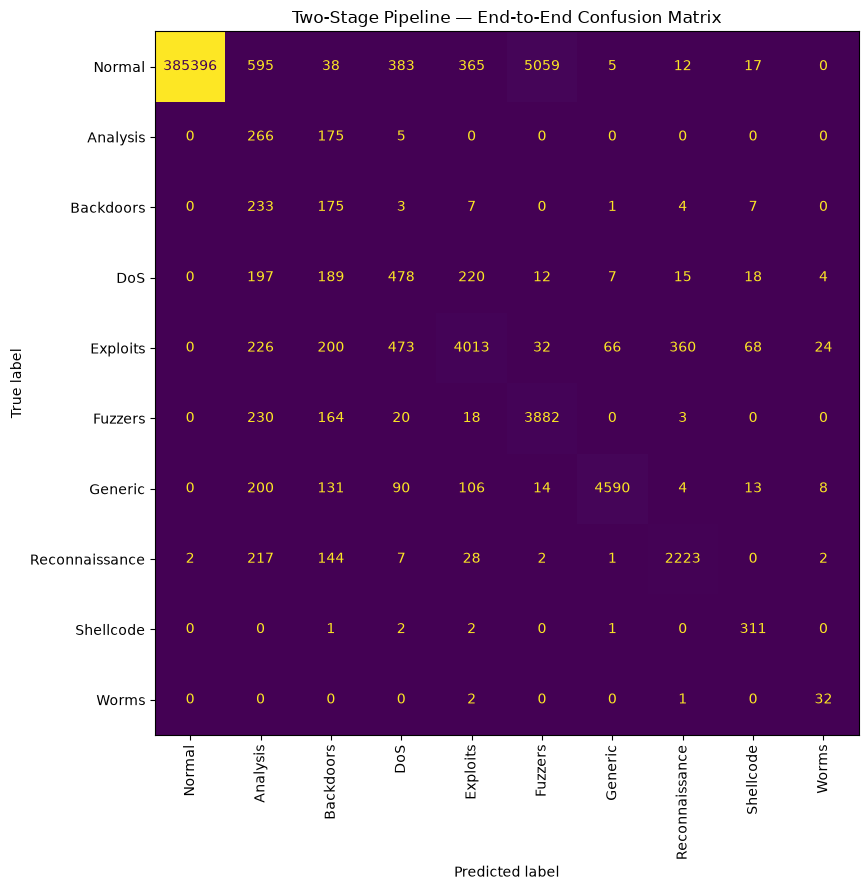

In [30]:
final_labels, s1_pred, s1_proba = two_stages_predict(x_test, stage1_model_xgboost_tuned, stage2_model_xgb_tuned, cat_encoder)
y_full_true = np.where(y_test == 0, "Normal", y_cat_test)

print(classification_report(y_full_true, final_labels, digits=3))

pipeline_cm_labels = ["Normal"] + list(cat_encoder.classes_)
cm_full = confusion_matrix(y_full_true, final_labels, labels=pipeline_cm_labels)

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm_full, display_labels=pipeline_cm_labels).plot(
    ax=ax, colorbar=False, xticks_rotation=90
)
ax.set_title("Two-Stage Pipeline — End-to-End Confusion Matrix")
plt.tight_layout()
plt.show()

### Prediction with Prioritization

In [38]:
CATEGORY_ABBREVIATION_MAP = {
    "A": "Analysis",
    "B": "Backdoors",
    "D": "DoS",
    "E": "Exploits",
    "F": "Fuzzers",
    "G": "Generic",
    "R": "Reconnaissance",
    "S": "Shellcode",
    "W": "Worms",
    "N": "Normal",
}
def two_stage_predict_with_confidence(X, stage1_model, stage2_model, cat_encoder,
                                       category_map=None):
    """
    Same as two_stages_predict, but also returns Stage 2's confidence
    (max predicted-class probability) for every row that reaches Stage 2.
    Rows Stage 1 calls Normal never reach Stage 2, so their category_confidence is 0.

    category_map : optional dict translating raw category codes (e.g. "F") to
                    full names (e.g. "Fuzzers"). Pass CATEGORY_ABBREVIATION_MAP
                    if cat_encoder.classes_ are abbreviated codes.

    Returns
    -------
    final_labels        : "Normal" or attack category name, per row
    stage1_pred          : binary Stage 1 predictions (0/1)
    stage1_proba         : Stage 1 predicted attack probability
    category_confidence  : Stage 2 max-class probability (0 for rows labeled Normal)
    """
    stage1_pred = stage1_model.predict(X)
    stage1_proba = stage1_model.predict_proba(X)[:, 1]

    n = X.shape[0]
    final_labels = np.full(n, "Normal", dtype=object)
    category_confidence = np.zeros(n)

    attack_idx = np.where(stage1_pred == 1)[0]
    if len(attack_idx) > 0:
        X_attack = X[attack_idx]
        stage2_proba_all = stage2_model.predict_proba(X_attack)
        stage2_pred_enc = np.argmax(stage2_proba_all, axis=1)
        stage2_pred = cat_encoder.inverse_transform(stage2_pred_enc)

        if category_map:
            stage2_pred = np.array(
                [category_map.get(lbl, lbl) for lbl in stage2_pred], dtype=object
            )

        final_labels[attack_idx] = stage2_pred
        category_confidence[attack_idx] = stage2_proba_all.max(axis=1)

    return final_labels, stage1_pred, stage1_proba, category_confidence


In [39]:
SEVERITY_WEIGHTS = {
    "Worms":          5,  
    "Shellcode":      5,  
    "Backdoors":      5,  
    "Backdoor":       5,  
    "Exploits":       4,  
    "DoS":            4,  
    "Generic":        3,  
    "Reconnaissance": 2,  
    "Analysis":       2,  
    "Fuzzers":        1,  
    "Normal":         0,
}
DEFAULT_SEVERITY = 3 
def compute_risk_scores(final_labels, stage1_proba, category_confidence,
                         severity_map=SEVERITY_WEIGHTS, default_severity=DEFAULT_SEVERITY):
    """
    trust      : how much the pipeline believes its own prediction
                 - Normal rows  -> stage1_proba is really "P(attack)", so trust in the
                   Normal call is (1 - stage1_proba)
                 - Attack rows  -> stage1_proba (confidence it's an attack at all) x
                   category_confidence (confidence in which attack)
    severity   : fixed weight of the predicted category (0 for Normal)
    risk_score : severity x trust in the underlying attack call (0 for Normal, since
                 there's nothing to prioritize if the pipeline says nothing is wrong)
    """
    is_normal = final_labels == "Normal"
    severity = np.array([severity_map.get(lbl, default_severity) for lbl in final_labels], dtype=float)

    trust = np.where(is_normal, stage1_proba, stage1_proba * category_confidence)
    risk_score = np.where(is_normal, 0.0, severity * trust)

    return risk_score, severity, trust


def assign_priority_tier(risk_score, max_severity=5):
    """Bucket risk_score (range 0..max_severity) into analyst-facing tiers."""
    tiers = np.full(len(risk_score), "Low", dtype=object)
    tiers[risk_score >= 0.15 * max_severity] = "Medium"
    tiers[risk_score >= 0.40 * max_severity] = "High"
    tiers[risk_score >= 0.70 * max_severity] = "Critical"
    tiers[risk_score == 0] = "None"
    return tiers


In [40]:
import os

ARTIFACT_DIR = "deployment_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

def artifact_path(filename):
    return os.path.join(ARTIFACT_DIR, filename)

joblib.dump(stage1_model_xgboost_tuned, artifact_path("stage1_xgboost_tuned.joblib"))
joblib.dump(stage2_model_xgb_tuned,     artifact_path("stage2_xgboost_tuned.joblib"))
joblib.dump(cat_encoder,                artifact_path("stage2_label_encoder.joblib"))

joblib.dump(preprocessing_pipeline, artifact_path("preprocessing_pipeline.joblib"))


joblib.dump(SEVERITY_WEIGHTS, artifact_path("risk_severity_weights.joblib"))

print("Deployment artifacts written to:", os.path.abspath(ARTIFACT_DIR))
for f in sorted(os.listdir(ARTIFACT_DIR)):
    size_kb = os.path.getsize(artifact_path(f)) / 1024
    print(f"  {f:<32} {size_kb:>10.1f} KB")


Deployment artifacts written to: d:\SIC\Projects\Project 2#\notebooks\deployment_artifacts
  preprocessing_pipeline.joblib           6.7 KB
  risk_severity_weights.joblib            0.2 KB
  stage1_xgboost_tuned.joblib            97.2 KB
  stage2_label_encoder.joblib             0.6 KB
  stage2_xgboost_tuned.joblib          6994.5 KB


In [ ]:
# TEST
stage1_deployed = joblib.load(artifact_path("stage1_xgboost_tuned.joblib"))
stage2_deployed = joblib.load(artifact_path("stage2_xgboost_tuned.joblib"))
encoder_deployed = joblib.load(artifact_path("stage2_label_encoder.joblib"))
severity_weights_deployed = joblib.load(artifact_path("risk_severity_weights.joblib"))

final_labels, s1_pred, s1_proba, s2_conf = two_stage_predict_with_confidence(
    x_test, stage1_deployed, stage2_deployed, encoder_deployed,
    category_map=CATEGORY_ABBREVIATION_MAP
)
risk_score, severity, trust = compute_risk_scores(
    final_labels, s1_proba, s2_conf, severity_map=severity_weights_deployed
)
priority = assign_priority_tier(risk_score)

print("Stage 2 category labels (cat_encoder.classes_):", list(encoder_deployed.classes_))
print("Stage 1 predicted-attack rate:", s1_pred.mean().round(4))
print("True attack rate in y_test:     ", y_test.mean().round(4))

# is_attack driven directly by Stage 1's hard prediction (0/1), not a string
# match against "Normal" -- robust regardless of how category names are encoded.
is_attack = s1_pred == 1

output = pd.DataFrame({
    "label": np.where(is_attack, "Attack", "Normal"),
    "attack_type": np.where(is_attack, final_labels, "--"),
    "priority": priority,
})

output


Stage 2 category labels (cat_encoder.classes_): ['Analysis', 'Backdoors', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']
Stage 1 predicted-attack rate: 0.0641
True attack rate in y_test:      0.0484


,label,attack_type,priority
0,Normal,--,None
1,Attack,Fuzzers,Low
2,Attack,Generic,High
3,Attack,Fuzzers,Low
4,Normal,--,None
...,...,...,...
411794,Normal,--,None
411795,Normal,--,None
411796,Normal,--,None
411797,Normal,--,None
